In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from imblearn.over_sampling import SMOTE
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model


In [24]:
from sklearn.datasets import load_breast_cancer
import pandas as pd

# Load dataset
data = load_breast_cancer()

# Convert to DataFrame
df = pd.DataFrame(data.data, columns=data.feature_names)

# Add target column
df['target'] = data.target

df.head()
X = df.drop(columns=['target'])
y = df['target']

In [25]:
print(df.info())

# Print first 5 rows
print(df.head())

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         569 non-null

In [26]:
# Standardizing the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
# Handle class imbalance
smote = SMOTE()
X_resampled, y_resampled = smote.fit_resample(X_scaled, y)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)


In [27]:
# Logistic Regression
log_model = LogisticRegression()
log_model.fit(X_train, y_train)
y_pred_log = log_model.predict(X_test)

In [28]:
# Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

In [29]:
# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# K-Means Clustering
kmeans = KMeans(n_clusters=2, random_state=42)
kmeans.fit(X_pca)
kmeans_labels = kmeans.labels_

In [30]:
# Pretrained ResNet Model (For Image Data)
resnet = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
resnet_model = Model(inputs=resnet.input, outputs=resnet.layers[-1].output)

In [31]:
# Confusion Matrix Visualization
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(title)
    plt.show()

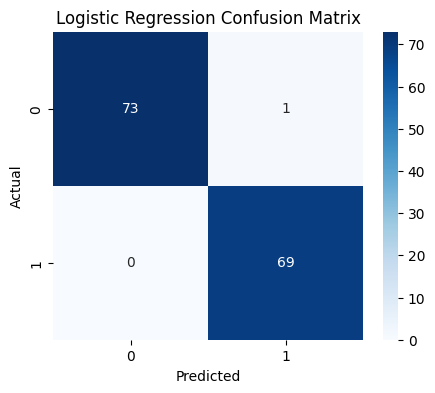

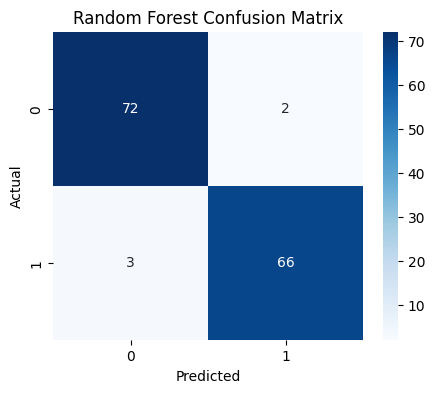

In [32]:
plot_confusion_matrix(y_test, y_pred_log, 'Logistic Regression Confusion Matrix')
plot_confusion_matrix(y_test, y_pred_rf, 'Random Forest Confusion Matrix')

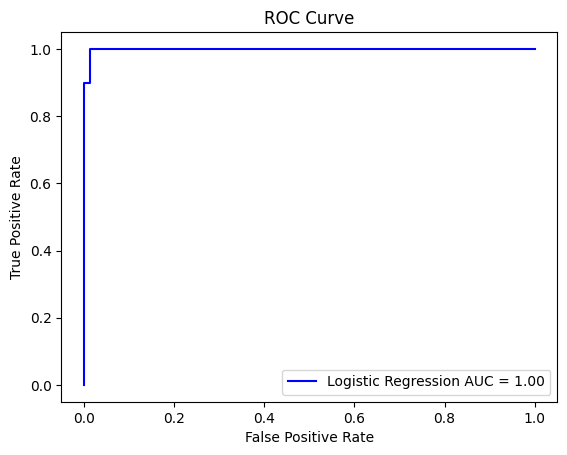

In [33]:
# ROC Curve
fpr, tpr, _ = roc_curve(y_test, log_model.predict_proba(X_test)[:, 1])
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, color='blue', label=f'Logistic Regression AUC = {roc_auc:.2f}')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

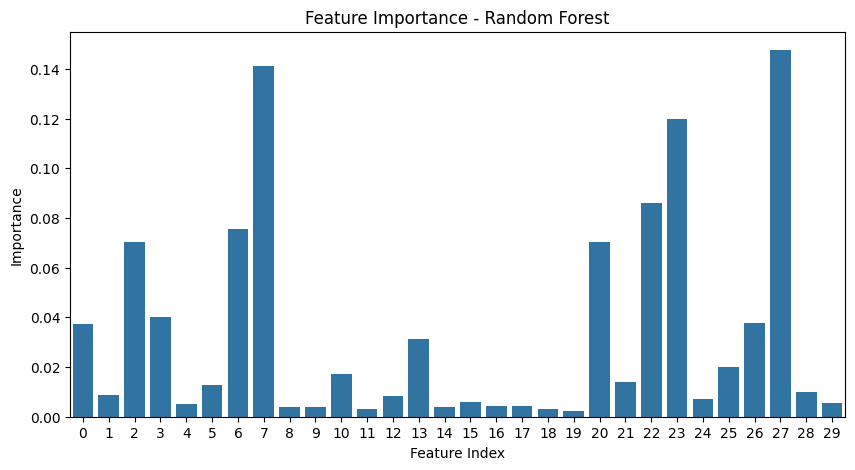

In [34]:
# Feature Importance (Random Forest)
importances = rf_model.feature_importances_
plt.figure(figsize=(10, 5))
sns.barplot(x=np.arange(len(importances)), y=importances)
plt.xlabel('Feature Index')
plt.ylabel('Importance')
plt.title('Feature Importance - Random Forest')
plt.show()

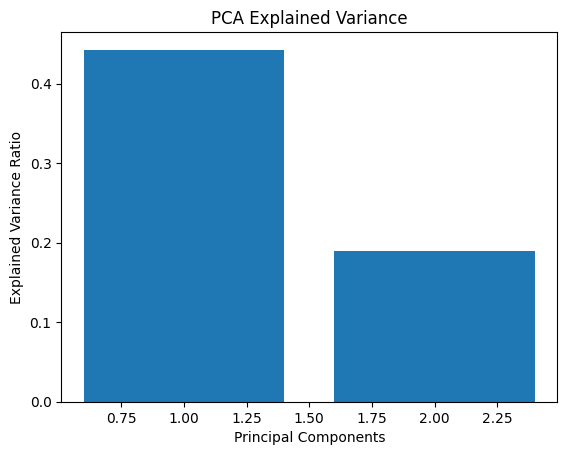

In [35]:
# PCA Explained Variance
plt.figure()
plt.bar(range(1, 3), pca.explained_variance_ratio_)
plt.xlabel('Principal Components')
plt.ylabel('Explained Variance Ratio')
plt.title('PCA Explained Variance')
plt.show()


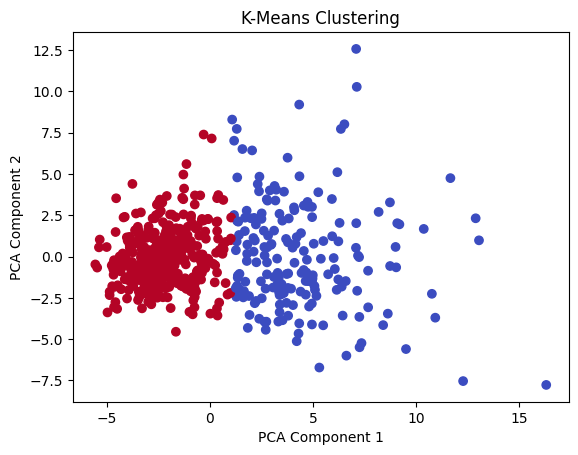

In [36]:
# K-Means Clustering Visualization
plt.figure()
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels, cmap='coolwarm')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('K-Means Clustering')
plt.show()


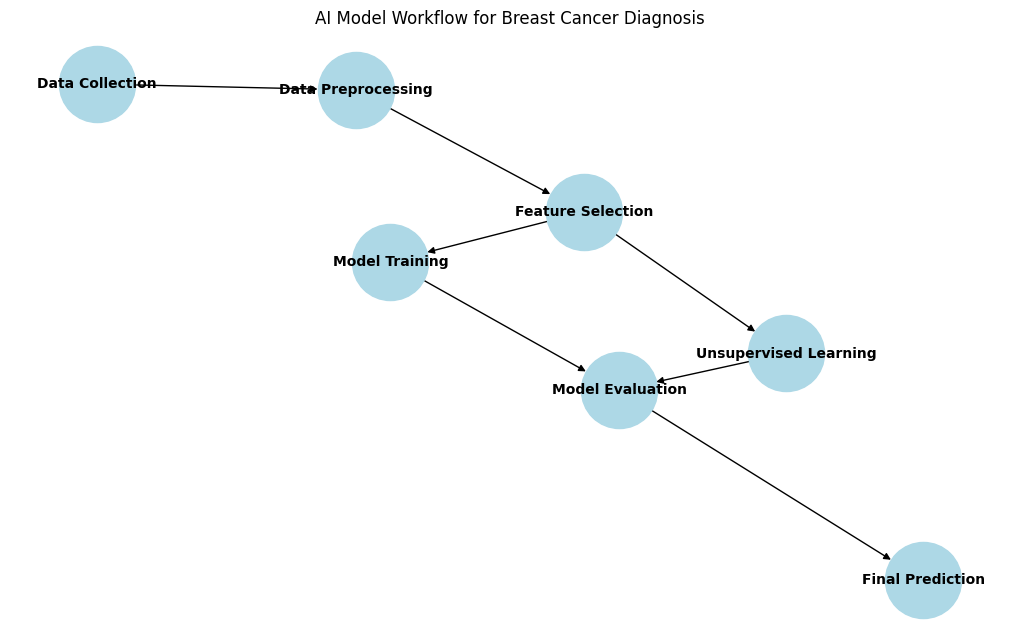

In [37]:
import matplotlib.pyplot as plt
import networkx as nx

# Create directed graph
G = nx.DiGraph()

# Define nodes
nodes = [
    "Data Collection", "Data Preprocessing", "Feature Selection", "Model Training",
    "Unsupervised Learning", "Model Evaluation", "Final Prediction"
]

# Define edges (workflow steps)
edges = [
    ("Data Collection", "Data Preprocessing"),
    ("Data Preprocessing", "Feature Selection"),
    ("Feature Selection", "Model Training"),
    ("Feature Selection", "Unsupervised Learning"),
    ("Model Training", "Model Evaluation"),
    ("Unsupervised Learning", "Model Evaluation"),
    ("Model Evaluation", "Final Prediction")
]

# Add nodes and edges to graph
G.add_nodes_from(nodes)
G.add_edges_from(edges)

# Layout for visualization
pos = nx.spring_layout(G, seed=42)

# Draw graph
plt.figure(figsize=(10, 6))
nx.draw(G, pos, with_labels=True, node_color='lightblue', edge_color='black', node_size=3000, font_size=10, font_weight='bold', arrows=True)
plt.title("AI Model Workflow for Breast Cancer Diagnosis")
plt.show()
